# V0 — Sequential vs Batched Inference

This notebook compares the latency of evaluating multiple Boolean
questions sequentially versus evaluating them in a single batch.

The goal is to measure how batching scales on local GPU hardware.

In [1]:
import time
import torch
import pandas as pd

from parallel_decider import BooleanQuestion, NLIBackend

In [2]:
backend = NLIBackend()

print("Device:", backend.device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/mebus/workspace/parallel-decider/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Device: cuda
GPU: NVIDIA GeForce RTX 3070


In [3]:
base_questions = [
    BooleanQuestion(
        name="needs_filesystem",
        hypothesis="This task requires filesystem access.",
    ),
    BooleanQuestion(
        name="needs_git",
        hypothesis="This task requires Git access.",
    ),
    BooleanQuestion(
        name="needs_shell",
        hypothesis="This task requires shell execution.",
    ),
    BooleanQuestion(
        name="needs_browser",
        hypothesis="This task requires browser access.",
    ),
    BooleanQuestion(
        name="needs_network",
        hypothesis="This task requires network access.",
    ),
    BooleanQuestion(
        name="needs_database",
        hypothesis="This task requires database access.",
    ),
    BooleanQuestion(
        name="needs_email",
        hypothesis="This task requires email access.",
    ),
    BooleanQuestion(
        name="needs_calendar",
        hypothesis="This task requires calendar access.",
    ),
    BooleanQuestion(
        name="needs_project_context",
        hypothesis="This task requires project-specific context.",
    ),
    BooleanQuestion(
        name="needs_user_context",
        hypothesis="This task requires user-specific context.",
    ),
    BooleanQuestion(
        name="needs_reasoning",
        hypothesis="This task requires substantial reasoning.",
    ),
    BooleanQuestion(
        name="has_side_effects",
        hypothesis="This task may cause external side effects.",
    ),
    BooleanQuestion(
        name="is_destructive",
        hypothesis="This task may perform destructive actions.",
    ),
    BooleanQuestion(
        name="needs_code_analysis",
        hypothesis="This task requires analysis of source code.",
    ),
    BooleanQuestion(
        name="needs_documentation",
        hypothesis="This task requires consulting documentation.",
    ),
    BooleanQuestion(
        name="needs_testing",
        hypothesis="This task requires running or inspecting tests.",
    ),
]

In [4]:
def make_questions(count: int) -> list[BooleanQuestion]:
    questions: list[BooleanQuestion] = []

    while len(questions) < count:
        for index, question in enumerate(base_questions):
            if len(questions) >= count:
                break

            questions.append(
                BooleanQuestion(
                    name=f"{question.name}_{len(questions)}",
                    hypothesis=question.hypothesis,
                )
            )

    return questions

In [5]:
for count in [1, 4, 8, 16, 32, 64]:
    questions = make_questions(count)
    print(count, len(questions), questions[0].name, questions[-1].name)

1 1 needs_filesystem_0 needs_filesystem_0
4 4 needs_filesystem_0 needs_browser_3
8 8 needs_filesystem_0 needs_calendar_7
16 16 needs_filesystem_0 needs_testing_15
32 32 needs_filesystem_0 needs_testing_31
64 64 needs_filesystem_0 needs_testing_63


In [6]:
def run_sequential(
    backend: NLIBackend,
    state: str,
    questions: list[BooleanQuestion],
):
    results = []

    for question in questions:
        result = backend.decide(
            state=state,
            questions=[question],
        )
        results.extend(result)

    return results

In [7]:
def run_batched(
    backend: NLIBackend,
    state: str,
    questions: list[BooleanQuestion],
):
    return backend.decide(
        state=state,
        questions=questions,
    )

In [8]:
state = """
Inspect the repository, identify which commit introduced the login bug,
run the relevant tests, compare the failing code with the documentation,
and explain the likely cause.
"""

In [9]:
questions = make_questions(8)

sequential = run_sequential(
    backend,
    state,
    questions,
)

batched = run_batched(
    backend,
    state,
    questions,
)

print(len(sequential))
print(len(batched))

8
8


In [10]:
for seq, batch in zip(sequential, batched):
    print(
        seq.name,
        f"{seq.probability:.4f}",
        f"{batch.probability:.4f}",
    )

needs_filesystem_0 0.8989 0.8989
needs_git_1 0.9136 0.9136
needs_shell_2 0.1016 0.1021
needs_browser_3 0.0362 0.0360
needs_network_4 0.2563 0.2563
needs_database_5 0.6396 0.6411
needs_email_6 0.0014 0.0014
needs_calendar_7 0.0001 0.0001


In [11]:
def measure_ms(fn, *args, warmup: int = 3, repeats: int = 10) -> float:
    for _ in range(warmup):
        fn(*args)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    timings = []

    for _ in range(repeats):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        fn(*args)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        timings.append((end - start) * 1000)

    return sum(timings) / len(timings)

In [12]:
questions = make_questions(8)

sequential_ms = measure_ms(
    run_sequential,
    backend,
    state,
    questions,
)

batched_ms = measure_ms(
    run_batched,
    backend,
    state,
    questions,
)

print(f"Sequential: {sequential_ms:.2f} ms")
print(f"Batched:    {batched_ms:.2f} ms")
print(f"Speedup:    {sequential_ms / batched_ms:.2f}x")

Sequential: 114.77 ms
Batched:    15.67 ms
Speedup:    7.33x


In [13]:
sizes = [1, 4, 8, 16, 32, 64]

benchmark_results = []

for size in sizes:
    questions = make_questions(size)

    sequential_ms = measure_ms(
        run_sequential,
        backend,
        state,
        questions,
    )

    batched_ms = measure_ms(
        run_batched,
        backend,
        state,
        questions,
    )

    benchmark_results.append(
        {
            "questions": size,
            "sequential_ms": sequential_ms,
            "batched_ms": batched_ms,
            "speedup": sequential_ms / batched_ms,
        }
    )

In [14]:
for row in benchmark_results:
    print(
        f"{row['questions']:>3} questions | "
        f"sequential {row['sequential_ms']:>8.2f} ms | "
        f"batched {row['batched_ms']:>8.2f} ms | "
        f"{row['speedup']:>5.2f}x"
    )

  1 questions | sequential    14.39 ms | batched    14.33 ms |  1.00x
  4 questions | sequential    58.03 ms | batched    14.80 ms |  3.92x
  8 questions | sequential   118.07 ms | batched    15.35 ms |  7.69x
 16 questions | sequential   226.20 ms | batched    15.86 ms | 14.26x
 32 questions | sequential   470.12 ms | batched    19.40 ms | 24.23x
 64 questions | sequential   908.54 ms | batched    33.82 ms | 26.86x


In [15]:
df = pd.DataFrame(benchmark_results)

df["sequential_ms"] = df["sequential_ms"].round(2)
df["batched_ms"] = df["batched_ms"].round(2)
df["speedup"] = df["speedup"].round(2)

df

,questions,sequential_ms,batched_ms,speedup
0,1,14.39,14.33,1.00
1,4,58.03,14.80,3.92
2,8,118.07,15.35,7.69
3,16,226.20,15.86,14.26
4,32,470.12,19.40,24.23
5,64,908.54,33.82,26.86


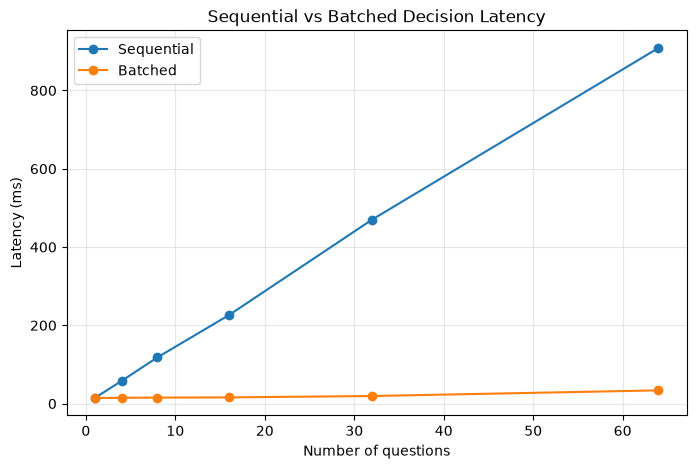

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df["questions"],
    df["sequential_ms"],
    marker="o",
    label="Sequential",
)

plt.plot(
    df["questions"],
    df["batched_ms"],
    marker="o",
    label="Batched",
)

plt.xlabel("Number of questions")
plt.ylabel("Latency (ms)")
plt.title("Sequential vs Batched Decision Latency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

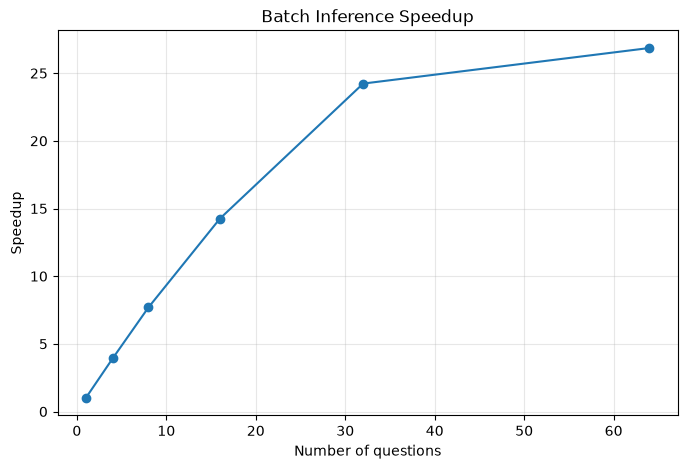

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["questions"],
    df["speedup"],
    marker="o",
)

plt.xlabel("Number of questions")
plt.ylabel("Speedup")
plt.title("Batch Inference Speedup")
plt.grid(True, alpha=0.3)

plt.show()

## Result

Batching provides substantial latency improvements as the number of
independent decisions increases.

On the test system:

- 1 question: ~1.0× speedup
- 8 questions: ~8× speedup
- 16 questions: ~12× speedup
- 32 questions: ~23× speedup
- 64 questions: ~28× speedup

The batched path grows from roughly 15 ms for a single question to only
about 34 ms for 64 questions, while sequential execution grows to almost
1 second.

This experiment still duplicates the state for every hypothesis inside
the batch. Shared-state inference is therefore a separate optimization
to investigate later.